# NBA Players — Exploratory Data Analysis (EDA)

**Tools used:** NumPy, Pandas, Matplotlib

This notebook explores a dataset of NBA players (name, team, position, age,
height, weight, college, salary) to answer questions like:

- How are players distributed by age, height, weight, and salary?
- Which teams have the highest payrolls?
- Is there a relationship between age and salary, or height and weight?
- Which positions tend to earn more?
- Which colleges produce the most NBA players?

The notebook is organized into 6 sections:
1. Data Loading & Inspection
2. Data Cleaning
3. Univariate Analysis (single-column distributions)
4. Categorical Analysis (teams, positions, colleges)
5. Bivariate / Correlation Analysis
6. Key Insights Summary


## 1. Data Loading & Inspection

We start by loading the raw CSV and understanding its shape, column types,
and the extent of missing data. This step never modifies the data — it's
purely diagnostic.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the raw dataset
df = pd.read_csv("data/nba.csv")

# The raw file has one fully-blank trailing row (a common export artifact) - drop it
df = df.dropna(how="all").reset_index(drop=True)

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (457, 9)


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0
2,John Holland,Boston Celtics,30.0,SG,27.0,6-5,205.0,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28.0,SG,22.0,6-5,185.0,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8.0,PF,29.0,6-10,231.0,NaN,5000000.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      457 non-null    str    
 1   Team      457 non-null    str    
 2   Number    457 non-null    float64
 3   Position  457 non-null    str    
 4   Age       457 non-null    float64
 5   Height    457 non-null    str    
 6   Weight    457 non-null    float64
 7   College   373 non-null    str    
 8   Salary    446 non-null    float64
dtypes: float64(4), str(5)
memory usage: 32.3 KB


In [3]:
# How much data is missing in each column?
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Name,0,0.00
Team,0,0.00
Number,0,0.00
Position,0,0.00
Age,0,0.00
Height,0,0.00
Weight,0,0.00
College,84,18.38
Salary,11,2.41


In [4]:
df.describe()  # summary stats for numeric columns only

,Number,Age,Weight,Salary
count,457.000000,457.000000,457.000000,4.460000e+02
mean,17.678337,26.938731,221.522976,4.842684e+06
std,15.966090,4.404016,26.368343,5.229238e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.044792e+06
50%,13.000000,26.000000,220.000000,2.839073e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


**Observation:** `Salary` has some missing values (players without a listed
salary, e.g. two-way / summer contracts), and `College` is missing for players
who went straight to the NBA (e.g. international players or high-school-to-pro
draftees, common before the one-and-done rule). We'll handle both in the
cleaning section.

## 2. Data Cleaning

Three cleaning tasks:
1. Convert `Height` from a string like `"6-2"` (feet-inches) into a single
   numeric column `Height_in` (total inches) — needed for any numeric/statistical work.
2. Handle missing `Salary` values.
3. Handle missing `College` values (label them `"None"` rather than dropping players).


In [5]:
# 1. Height: "6-2" -> 74 inches, using vectorized string ops (fast, no row-by-row loop)
height_parts = df["Height"].str.split("-", expand=True).astype(int)
df["Height_in"] = height_parts[0] * 12 + height_parts[1]

df[["Height", "Height_in"]].head()

,Height,Height_in
0,6-2,74
1,6-6,78
2,6-5,77
3,6-5,77
4,6-10,82


In [6]:
# 2. Salary: fill missing values with the median (robust to outliers/superstar salaries)
# We keep the original column intact and create a cleaned version.
salary_median = df["Salary"].median()
df["Salary_clean"] = df["Salary"].fillna(salary_median)

print(f"Median salary used to fill missing values: ${salary_median:,.0f}")
print("Missing salaries remaining:", df["Salary_clean"].isnull().sum())

Median salary used to fill missing values: $2,839,073
Missing salaries remaining: 0


In [7]:
# 3. College: missing means no US college was attended
df["College"] = df["College"].fillna("None")
print("Missing colleges remaining:", df["College"].isnull().sum())

Missing colleges remaining: 0


In [8]:
# Quick re-check after cleaning
df[["Height_in", "Salary_clean", "College"]].isnull().sum()

Height_in       0
Salary_clean    0
College         0
dtype: int64

## 3. Univariate Analysis

Looking at one column at a time: how is Age, Height, Weight, and Salary
distributed across all players?

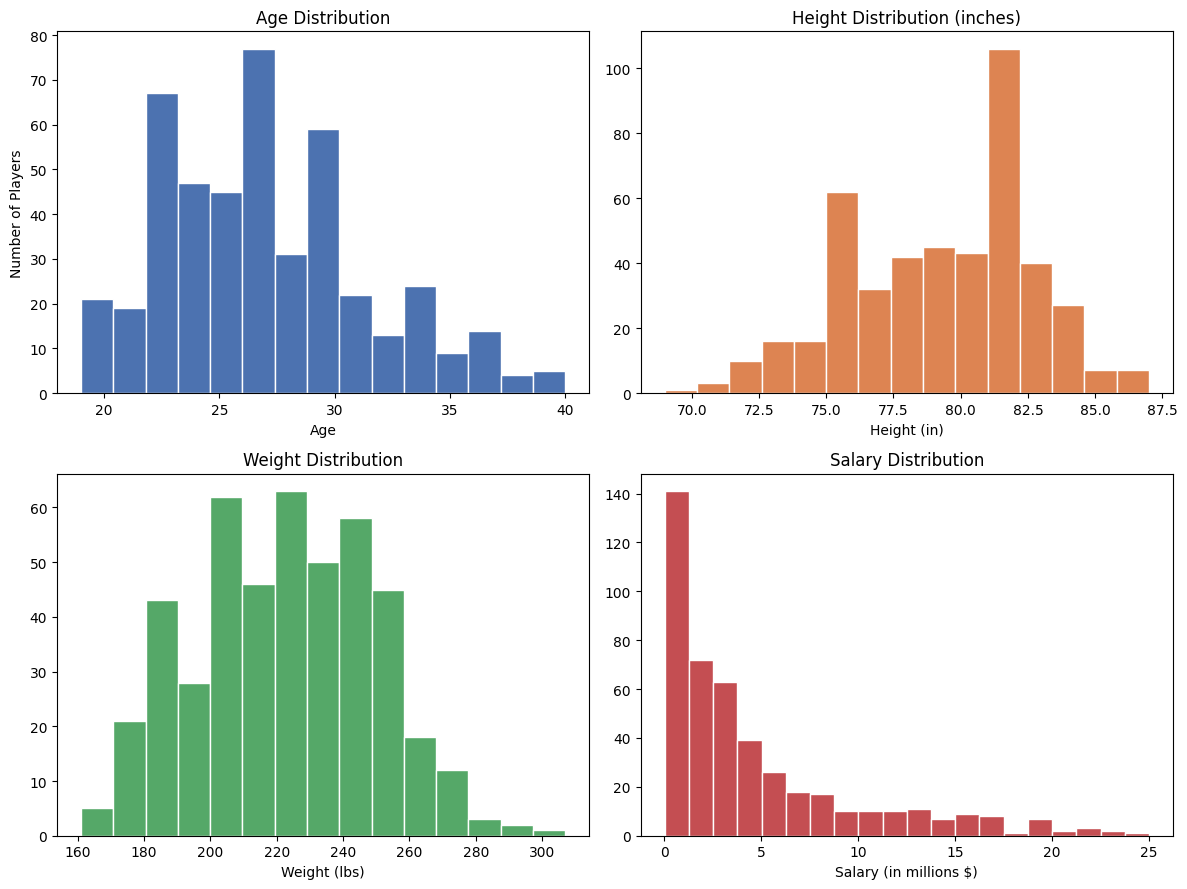

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0,0].hist(df["Age"], bins=15, color="#4C72B0", edgecolor="white")
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Number of Players")

axes[0,1].hist(df["Height_in"], bins=15, color="#DD8452", edgecolor="white")
axes[0,1].set_title("Height Distribution (inches)")
axes[0,1].set_xlabel("Height (in)")

axes[1,0].hist(df["Weight"], bins=15, color="#55A868", edgecolor="white")
axes[1,0].set_title("Weight Distribution")
axes[1,0].set_xlabel("Weight (lbs)")

axes[1,1].hist(df["Salary_clean"] / 1e6, bins=20, color="#C44E52", edgecolor="white")
axes[1,1].set_title("Salary Distribution")
axes[1,1].set_xlabel("Salary (in millions $)")

plt.tight_layout()
plt.savefig("images/01_univariate_distributions.png", dpi=120)
plt.show()

In [10]:
# NumPy-based descriptive statistics (mean, median, std, variance) computed manually
for col, label in [("Age", "Age"), ("Height_in", "Height (in)"),
                   ("Weight", "Weight (lb)"), ("Salary_clean", "Salary ($)")]:
    arr = df[col].to_numpy()
    print(f"--- {label} ---")
    print(f"Mean:     {np.mean(arr):,.2f}")
    print(f"Median:   {np.median(arr):,.2f}")
    print(f"Std Dev:  {np.std(arr):,.2f}")
    print(f"Variance: {np.var(arr):,.2f}")
    print()

--- Age ---
Mean:     26.94
Median:   26.00
Std Dev:  4.40
Variance: 19.35

--- Height (in) ---
Mean:     79.19
Median:   80.00
Std Dev:  3.43
Variance: 11.76

--- Weight (lb) ---
Mean:     221.52
Median:   220.00
Std Dev:  26.34
Variance: 693.77

--- Salary ($) ---
Mean:     4,794,457.14
Median:   2,839,073.00
Std Dev:  5,169,255.21
Variance: 26,721,199,416,883.89



**Observation:** Salary is heavily **right-skewed** — most players earn a
modest amount, but a small number of superstars earn tens of millions,
pulling the mean above the median. Age and Height are roughly bell-shaped
(normal-ish), which makes sense biologically and career-wise.

## 4. Categorical Analysis

Now we look at grouped/categorical data: how many players per team, per
position, and where they went to college.

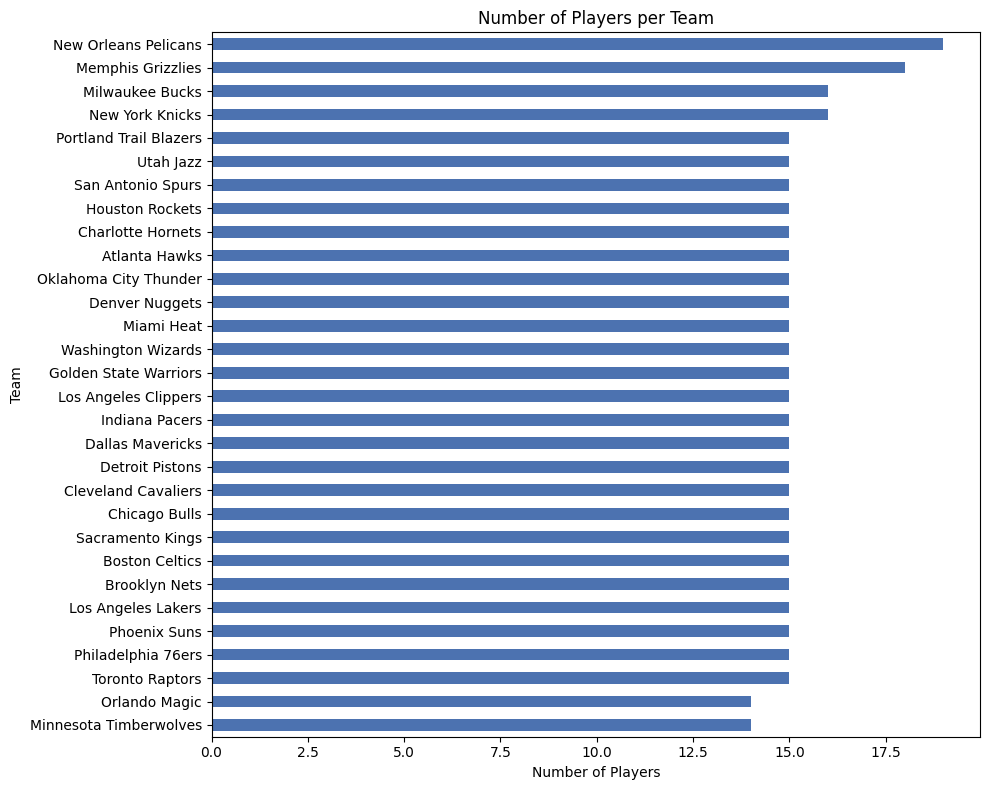

In [11]:
team_counts = df["Team"].value_counts()

plt.figure(figsize=(10,8))
team_counts.sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Number of Players per Team")
plt.xlabel("Number of Players")
plt.tight_layout()
plt.savefig("images/02_players_per_team.png", dpi=120)
plt.show()

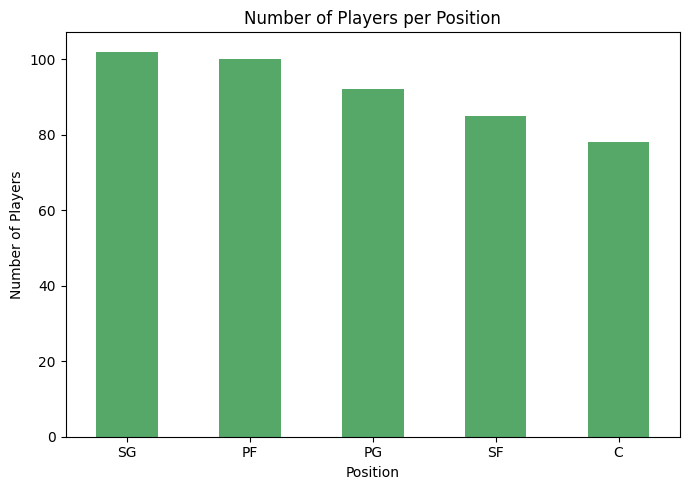

In [12]:
position_counts = df["Position"].value_counts()

plt.figure(figsize=(7,5))
position_counts.plot(kind="bar", color="#55A868")
plt.title("Number of Players per Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/03_players_per_position.png", dpi=120)
plt.show()

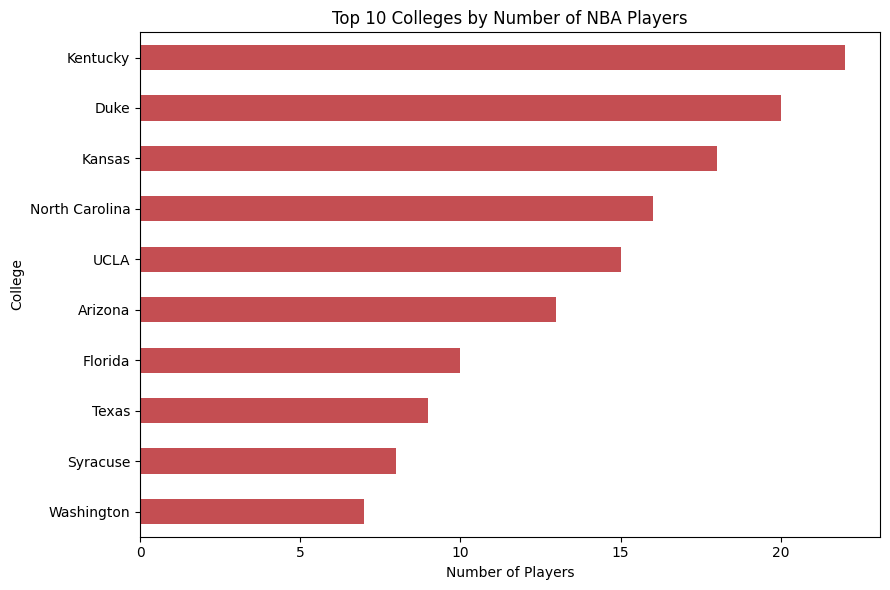

In [13]:
top_colleges = df["College"].value_counts().drop("None", errors="ignore").head(10)

plt.figure(figsize=(9,6))
top_colleges.sort_values().plot(kind="barh", color="#C44E52")
plt.title("Top 10 Colleges by Number of NBA Players")
plt.xlabel("Number of Players")
plt.tight_layout()
plt.savefig("images/04_top_colleges.png", dpi=120)
plt.show()

## 5. Bivariate & Correlation Analysis

Do older players earn more? Are taller players heavier? Which positions pay
the most on average? We use `np.corrcoef` for correlation and grouped means
for the position/team comparisons.

Correlation between Age and Salary: 0.209


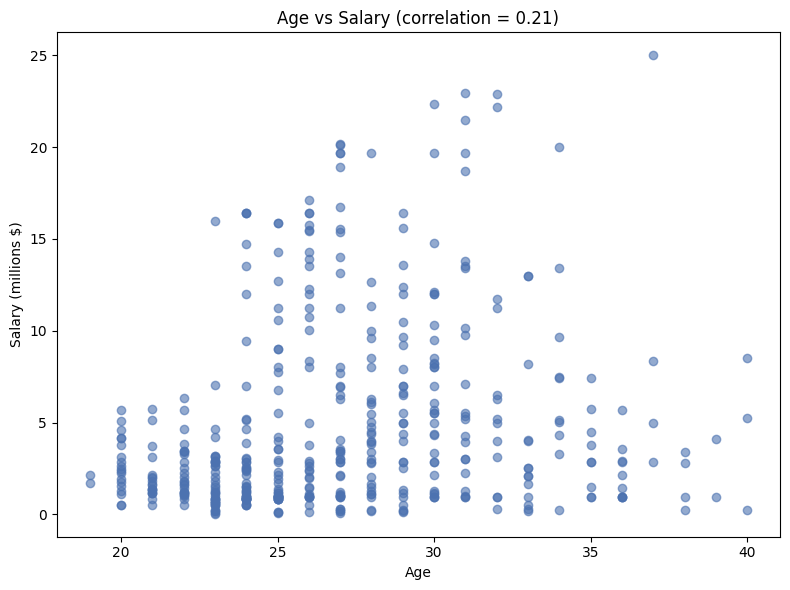

In [14]:
# Age vs Salary
age_salary_corr = np.corrcoef(df["Age"], df["Salary_clean"])[0,1]
print(f"Correlation between Age and Salary: {age_salary_corr:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(df["Age"], df["Salary_clean"]/1e6, alpha=0.6, color="#4C72B0")
plt.title(f"Age vs Salary (correlation = {age_salary_corr:.2f})")
plt.xlabel("Age")
plt.ylabel("Salary (millions $)")
plt.tight_layout()
plt.savefig("images/05_age_vs_salary.png", dpi=120)
plt.show()

Correlation between Height and Weight: 0.828


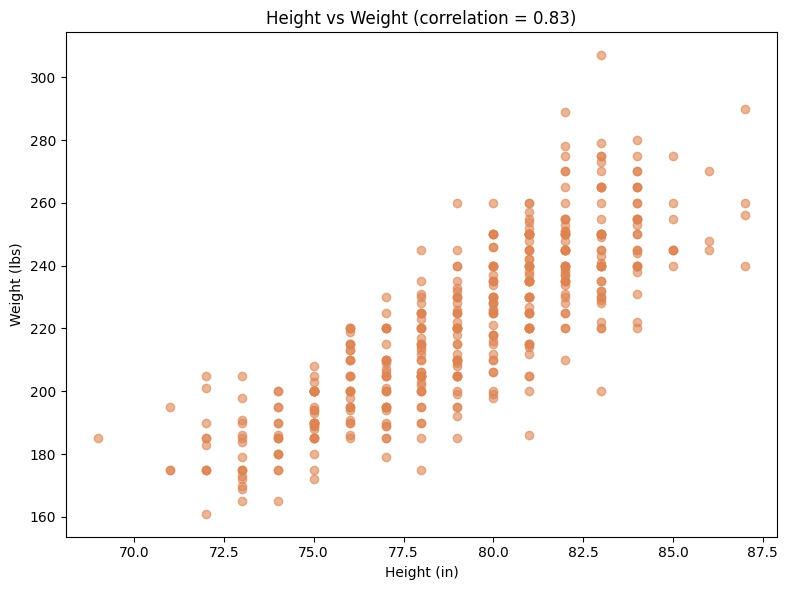

In [15]:
# Height vs Weight
height_weight_corr = np.corrcoef(df["Height_in"], df["Weight"])[0,1]
print(f"Correlation between Height and Weight: {height_weight_corr:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(df["Height_in"], df["Weight"], alpha=0.6, color="#DD8452")
plt.title(f"Height vs Weight (correlation = {height_weight_corr:.2f})")
plt.xlabel("Height (in)")
plt.ylabel("Weight (lbs)")
plt.tight_layout()
plt.savefig("images/06_height_vs_weight.png", dpi=120)
plt.show()

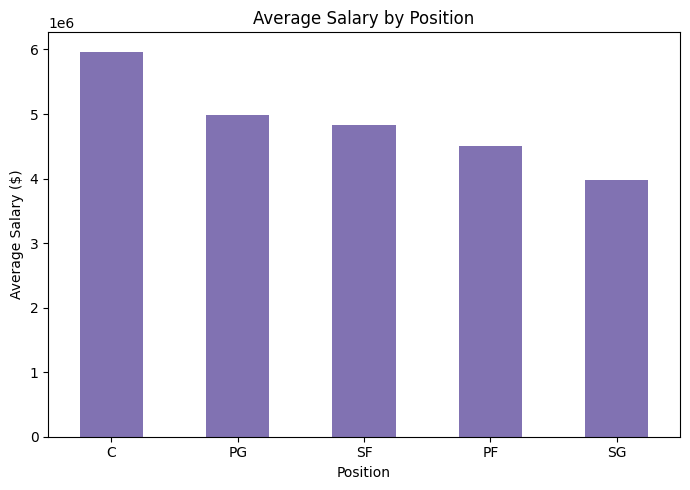

Position
C     5.967052e+06
PG    4.980492e+06
SF    4.833648e+06
PF    4.510781e+06
SG    3.975426e+06
Name: Salary_clean, dtype: float64

In [16]:
# Average salary by position
avg_salary_by_position = df.groupby("Position")["Salary_clean"].mean().sort_values(ascending=False)

plt.figure(figsize=(7,5))
avg_salary_by_position.plot(kind="bar", color="#8172B2")
plt.title("Average Salary by Position")
plt.ylabel("Average Salary ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/07_avg_salary_by_position.png", dpi=120)
plt.show()

avg_salary_by_position

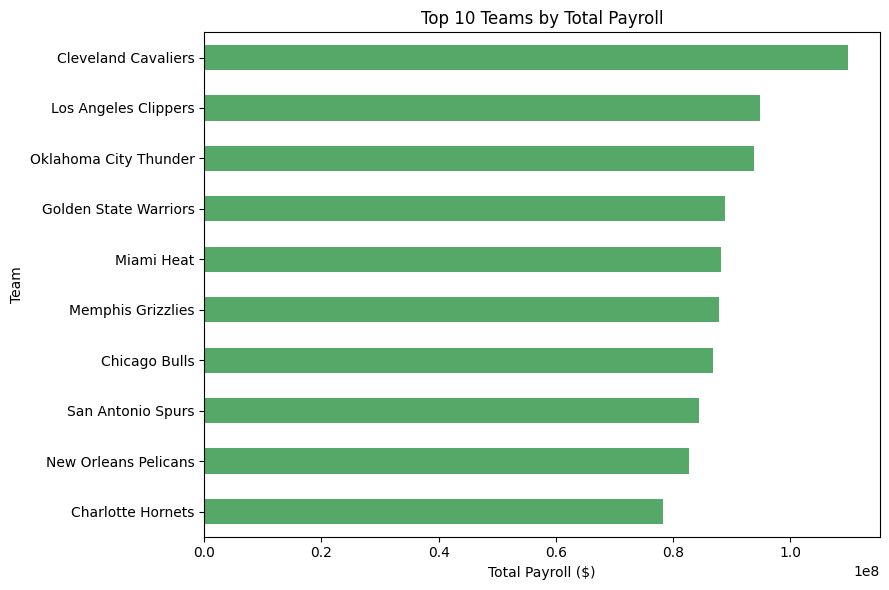

Team
Cleveland Cavaliers      109827762.0
Los Angeles Clippers      94854640.0
Oklahoma City Thunder     93765298.0
Golden State Warriors     88868997.0
Miami Heat                88193819.0
Memphis Grizzlies         87907172.0
Chicago Bulls             86783378.0
San Antonio Spurs         84442733.0
New Orleans Pelicans      82750774.0
Charlotte Hornets         78340920.0
Name: Salary_clean, dtype: float64

In [17]:
# Total payroll by team (sum of salaries) - top 10
team_payroll = df.groupby("Team")["Salary_clean"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,6))
team_payroll.sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 10 Teams by Total Payroll")
plt.xlabel("Total Payroll ($)")
plt.tight_layout()
plt.savefig("images/08_top_team_payroll.png", dpi=120)
plt.show()

team_payroll

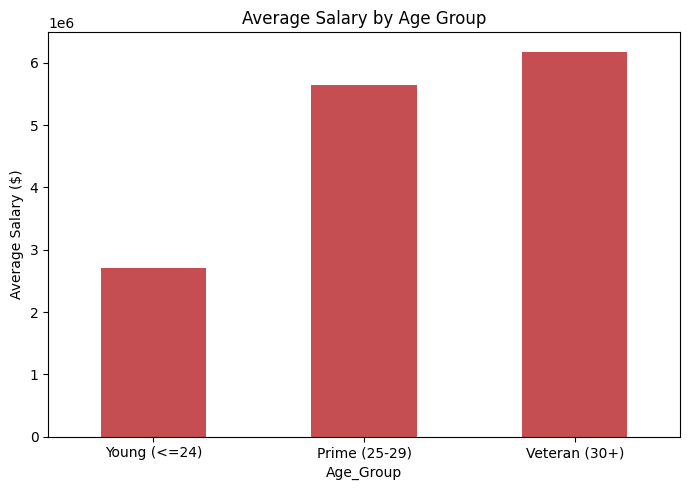

Age_Group
Young (<=24)     2.709663e+06
Prime (25-29)    5.635022e+06
Veteran (30+)    6.179016e+06
Name: Salary_clean, dtype: float64

In [18]:
# Age buckets vs average salary (np.where / pd.cut combo)
bins = [0, 24, 29, 100]
labels = ["Young (<=24)", "Prime (25-29)", "Veteran (30+)"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group_salary = df.groupby("Age_Group")["Salary_clean"].mean()

plt.figure(figsize=(7,5))
age_group_salary.plot(kind="bar", color="#C44E52")
plt.title("Average Salary by Age Group")
plt.ylabel("Average Salary ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/09_salary_by_age_group.png", dpi=120)
plt.show()

age_group_salary

## 6. Key Insights Summary

Based on the analysis above:

1. **Salary is right-skewed** — a small number of star players earn far above
   the median, pulling the average salary well above what a "typical" player earns.
2. **Age and Salary are positively correlated** (see correlation value above) —
   veteran players tend to earn more, likely reflecting experience and
   long-term/max contracts, up to a point.
3. **Height and Weight are strongly positively correlated**, as expected —
   taller players are generally heavier.
4. **Centers (C) and Power Forwards (PF)** tend to have the highest average
   salaries among positions in this dataset, while guards are more variable.
5. A handful of teams carry a **disproportionately large share of total
   payroll**, reflecting differences in team strategy (stars vs. depth).
6. **Age groups**: Veteran players (30+) earn noticeably more on average than
   young players, consistent with the age-salary correlation.

*(Exact numbers will print when you run the notebook — use them to back up
each point when explaining this project to someone else.)*
